In [29]:
import osyris
import numpy as np

In [31]:
nout=2
outer_boundary = 3.
alpha=0.1
H_over_R=0.1
nr=30

mydata = osyris.RamsesDataset(path='.',nout=nout)
mydata.load()
mesh = mydata["mesh"]

disk_density   = 1.0
inner_boundary = np.min(mesh["dx"]).values

t =  mydata.meta['time'].magnitude# c.u.
t_Porb = int(t / (2.*np.pi))
t_nu = outer_boundary**1.5  / (3./2. * alpha * H_over_R**2. )
print(f"t_nu[outer_boundary]= {t_nu}")

dr = (outer_boundary - inner_boundary)/nr
range_r = np.arange(inner_boundary,outer_boundary,dr)
density = np.zeros(nr) ; vr = np.zeros(nr) ; vphi = np.zeros(nr); r = np.zeros(nr)


center = np.array([4,4])  * osyris.units('cm')
mesh["centered_position"] =  osyris.Vector((mesh["position"].x - center[0])  , (mesh["position"].y - center[1]))

mesh["volume"] = mesh["dx"]**2.
mesh["r"] = mesh["centered_position"].norm
mesh["vr"] = mesh["velocity"].dot(mesh["centered_position"])/mesh["r"]
mesh["vphi"] = (mesh["velocity"].x * mesh["centered_position"].y - mesh["velocity"].y * mesh["centered_position"].x)/mesh["r"]


for i in range(nr):
    r_min = range_r[i]
    if i < nr - 1 :
        r_max = range_r[i+1]
    else :
        r_max = range_r[i] + dr

    ring = np.where((mesh["r"].values >= r_min) & ( mesh["r"].values <= r_max))
    
    density_ring = mesh["density"].values[ring]
    vr_ring      = mesh["vr"].values[ring]
    vphi_ring    = mesh["vphi"].values[ring]
    volume_ring  = mesh["volume"].values[ring]

    density[i] = np.nansum(density_ring*volume_ring)/np.nansum(volume_ring)
    vr[i] = np.nansum(vr_ring*volume_ring)/np.nansum(volume_ring)
    vphi[i] = np.nansum(vphi_ring*volume_ring)/np.nansum(volume_ring)

    density_t0_r0 = disk_density
    density[i] = density[i] / density_t0_r0
    r[i] = (r_min + r_max)/2.
    
result = {'r':r,'density':density,'vr':vr,'vphi':vphi}

Processing 1 files in ./output_00002
Loaded: 4504612 cells, 0 particles.
t_nu[outer_boundary]= 3464.1016151377535


Text(0, 0.5, 'density')

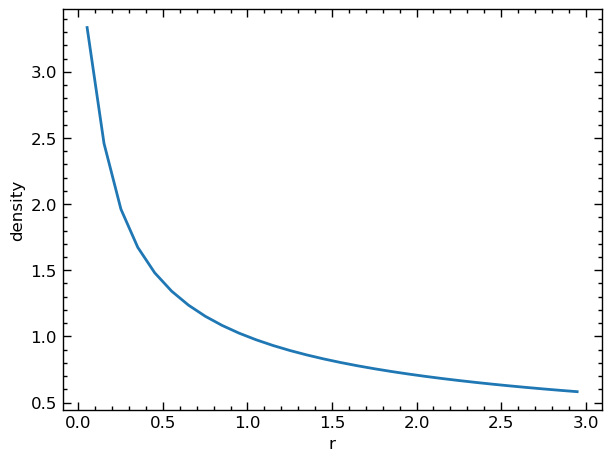

In [32]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(result['r'],result['density'])
plt.xlabel('r')
plt.ylabel('density')


Text(0, 0.5, 'vr')

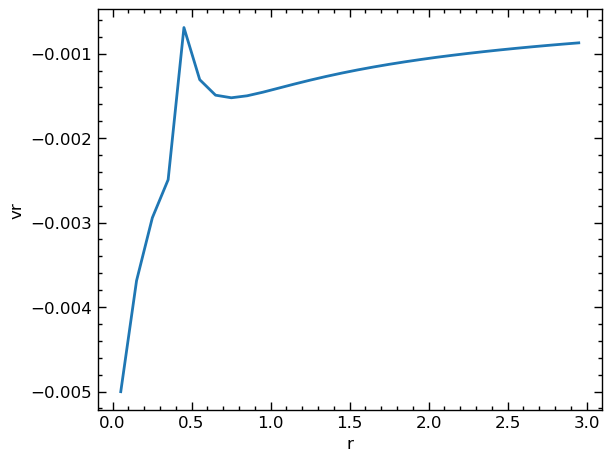

In [34]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(result['r'],result['vr'])
plt.xlabel('r')
plt.ylabel('vr')


Text(0, 0.5, 'vphi')

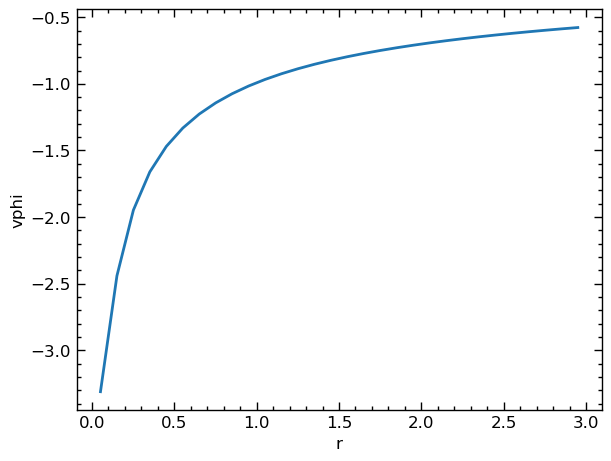

In [35]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(result['r'],result['vphi'])
plt.xlabel('r')
plt.ylabel('vphi')


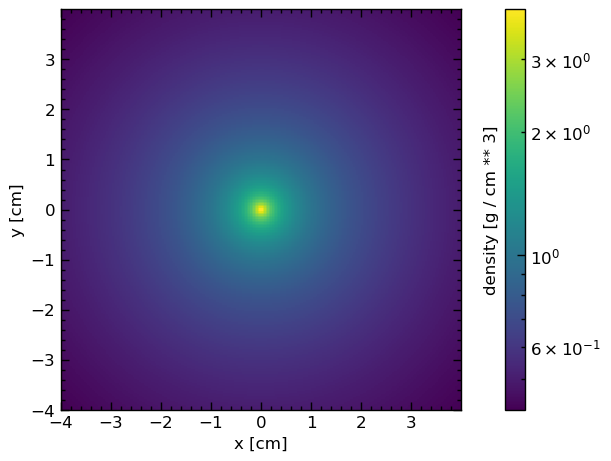

In [36]:

ind = np.argmax(mesh["density"])
center = mesh["position"][ind]
osyris.map(mesh.layer("density"),
    norm="log",
    origin=center,
    direction="z",
)


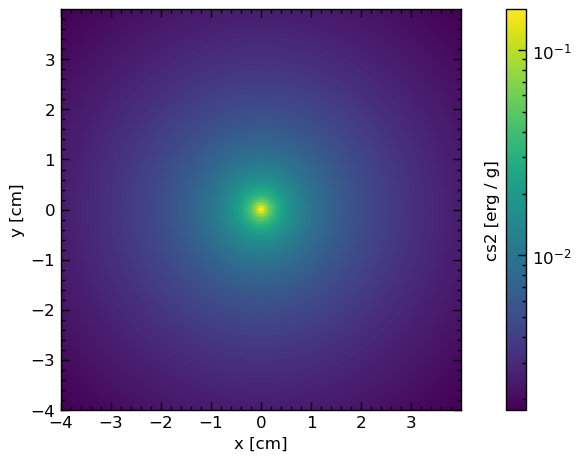

In [37]:


mesh["cs2"] = mesh["pressure"]/mesh["density"]

osyris.map(mesh.layer("cs2"),
    norm="log",
    origin=center,
    direction="z",
)


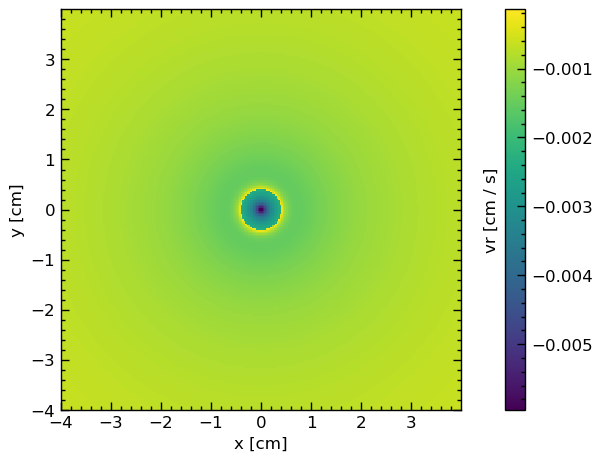

In [39]:

osyris.map(mesh.layer("vr"),
    norm="linear",
    origin=center,
    direction="z",

    
)
